# Physics-Informed Inverse Rheology: Power-Law Fluid Parameters from Cone-Plate Descent Curves

## What this notebook does

The instrument records torque **while the cone spindle is still descending** toward the plate,
before the true zero gap ("hit point") is reached. This notebook uses a **physics-informed
inverse model** to read that descent curve and simultaneously solve, per sample, for:

- **k** and **n** — the power-law constitutive parameters of the fluid ( τ = k·γ̇ⁿ )
- **h0** — the true zero-gap position, which the instrument does not directly report

Instead of the usual "fit shear stress vs. shear rate" approach (which needs the gap to already
be known), we embed the actual **momentum balance of the fluid in the cone-plate gap** into a
small differentiable PyTorch model, and let gradient descent find the (k, n, h0) that best explain
the raw `Torque_%` vs. `Z_Height_mm` curve for each sample.

## Why this counts as "physics-informed"

There is no black-box neural network here. The physics equation itself (rotational-drag balance
for a power-law fluid in a thin, radius-dependent gap) *is* the model. Its only learnable weights
are the three physical unknowns (k, n, h0), and PyTorch's autograd trains them exactly the way it
would train a network — by back-propagating the mismatch between predicted and measured torque
through the physics equations.

*(A full 3D Navier–Stokes PINN — a neural velocity field trained against PDE-residual collocation
points, e.g. with DeepXDE or NVIDIA Modulus — is the natural next step and is discussed at the end.
This notebook keeps the same core idea but in a simplified 1D lubrication-theory form, so the whole
pipeline is easy to read top to bottom.)*

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 100

## 1. Load and explore the raw data

Each row is one instant during a descent sweep: the spindle sits at position `Z_Height_mm`,
spinning at a fixed `RPM` for the whole run, and the instrument reports `Torque_%` (percent of
full-scale torque). `Rotational_Drag` (= Torque_% / RPM) is already provided as a quick-look
metric, but we work from `Torque_%` directly since that is what the physics model predicts.

Each `Cell_Label` is one sample (PEG concentration % + molecular weight) run on one cell/spindle.
Some samples were re-run under a differently-spelled label (e.g. `5%300K_0.577` vs. `300K5%_0.577`
vs. `300K_5%_PEG`) — we use those as a repeatability check later.

In [2]:
df = pd.read_csv("all_PEG.csv")

print(f"{len(df)} rows, {df['Cell_Label'].nunique()} sample runs")

summary = df.groupby("Cell_Label").agg(
    n_points=("Torque_%", "size"),
    rpm=("RPM", "first"),
    z_min_mm=("Z_Height_mm", "min"),
    z_max_mm=("Z_Height_mm", "max"),
).sort_values("rpm", ascending=False)

summary

498 rows, 12 sample runs


,n_points,rpm,z_min_mm,z_max_mm
Cell_Label,,,,
300K5%_0.577,39,90.0,-66.50,-65.74
300K_5%_PEG,35,90.0,-66.42,-65.74
5%300K_0.577,39,90.0,-66.50,-65.74
5%600K_3.254,44,15.0,-66.28,-65.42
600K5%_3.254,45,15.0,-66.30,-65.42
6.5%600K_4.109,40,12.0,-66.26,-65.48
600K_6.5%_PEG,35,12.0,-66.24,-65.56
600K6.5%_4.109,43,12.0,-66.32,-65.48
10%300K_7.158,43,7.0,-66.40,-65.56


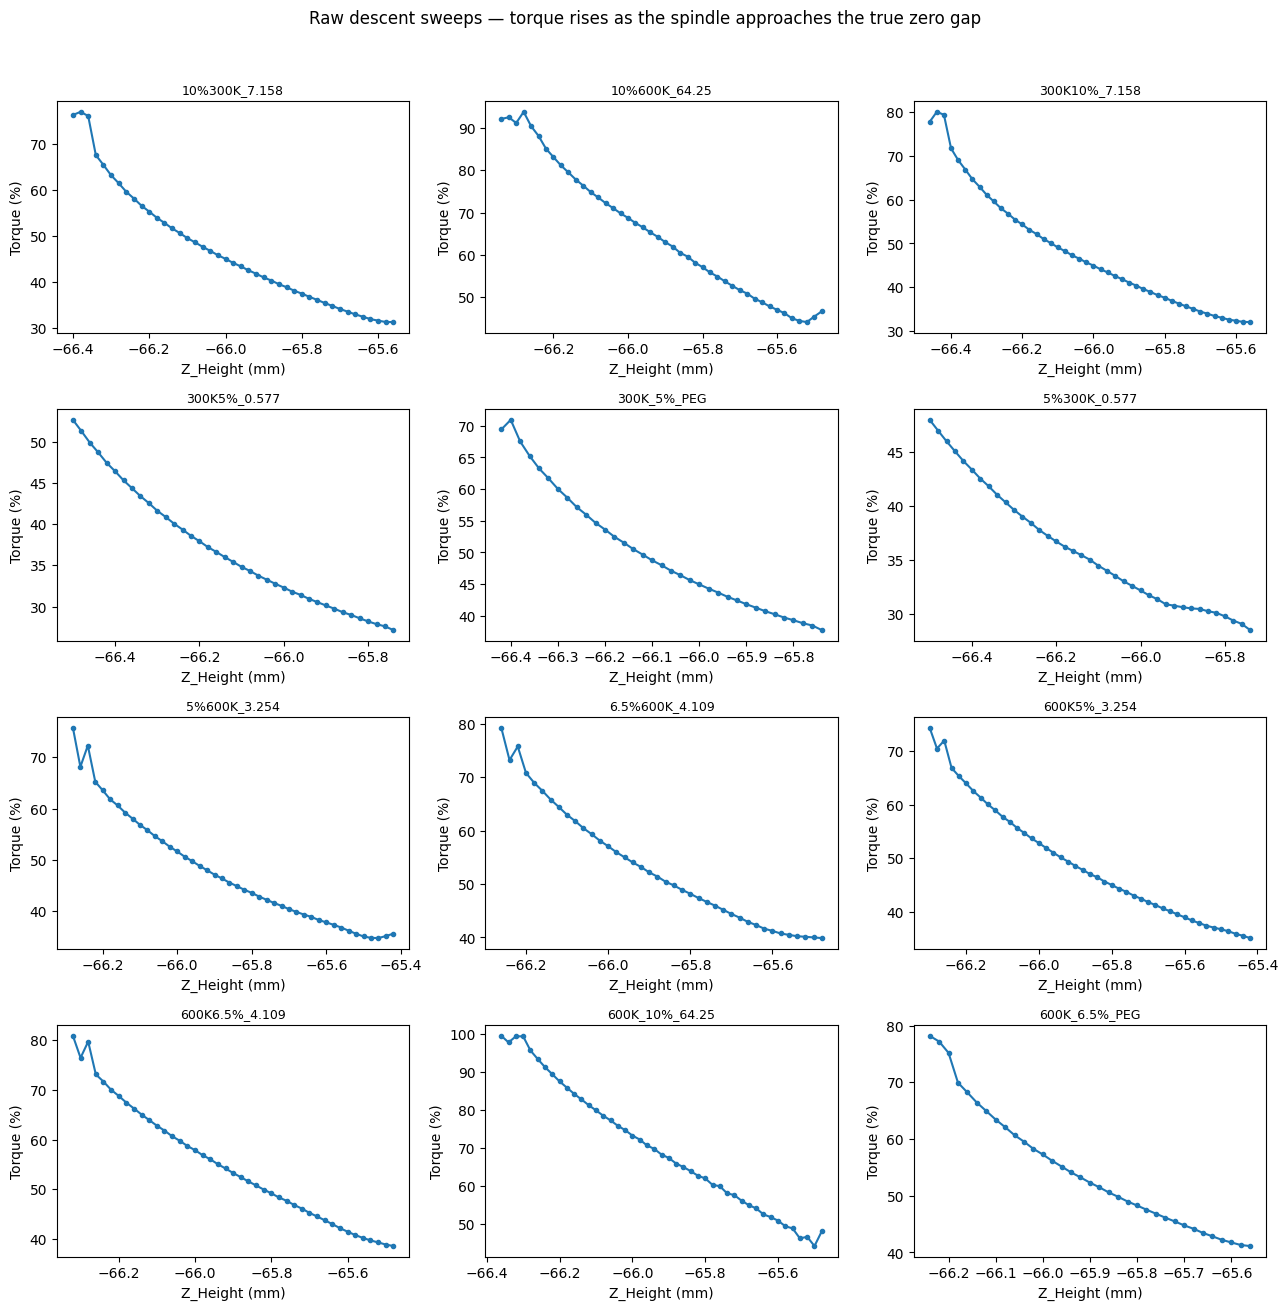

In [3]:
# Raw descent sweeps: torque should climb as Z drops toward the (unknown) true zero gap
labels = sorted(df["Cell_Label"].unique())
n_cols = 3
n_rows = int(np.ceil(len(labels) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.2 * n_rows))
for ax, label in zip(axes.flat, labels):
    g = df[df["Cell_Label"] == label].sort_values("Z_Height_mm")
    ax.plot(g["Z_Height_mm"], g["Torque_%"], "o-", ms=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Z_Height (mm)")
    ax.set_ylabel("Torque (%)")
for ax in axes.flat[len(labels):]:
    ax.axis("off")

fig.suptitle("Raw descent sweeps — torque rises as the spindle approaches the true zero gap", y=1.02)
plt.tight_layout()
plt.show()

## 2. The physics: why torque rises as Z decreases

The instrument lowers a cone spindle toward a flat plate holding the sample. If the cone's true
apex touched the plate exactly, the gap at every radius `r` would just be `r·tan(θ)` (θ = cone
half-angle), giving a *uniform* shear rate everywhere — the whole point of a cone-plate geometry.
In practice, the spindle's reported position `Z` sits at some unknown offset from that true zero,
`h0`. So the real gap at radius `r` is:

$$h(r) = (Z - h_0) + r\tan\theta$$

As the spindle descends, `Z` decreases, the offset `(Z - h0)` shrinks, the gap closes up
everywhere, shear rates rise, and torque increases — exactly the trend in the plots above.

**Local shear rate** at radius `r` (thin-gap / lubrication approximation — valid because the gap
is always much smaller than the cone radius):

$$\dot\gamma(r) = \frac{\Omega r}{h(r)}, \qquad \Omega = \frac{2\pi \cdot \text{RPM}}{60}$$

**Power-law constitutive law** — what we actually want to solve for:

$$\tau(r) = k\,\dot\gamma(r)^n$$

**Torque** is the integral of shear stress × lever arm, over the whole cone face:

$$M = \int_0^R \tau(r)\, r \,(2\pi r)\, dr = 2\pi k \Omega^n \int_0^R \frac{r^{\,n+2}}{h(r)^n}\, dr$$

This integral has no closed form for a general offset + general `n`, but it is trivial to evaluate
numerically. And because every step is a standard tensor operation, it is automatically
differentiable with respect to `k`, `n`, and `h0` — which is exactly what lets us fit them with
gradient descent, the same way you would train a neural network.

## 3. Instrument constants

**Replace these with your spindle's actual values from its calibration certificate / spec sheet.**
The fit is only as physically meaningful as these numbers — the angle and radius below are
placeholders, everything downstream (`k` in particular) scales with them.

In [4]:
TORQUE_FULL_SCALE_DYNE_CM = 7180.0   # given: Torque_% is a percentage of this full-scale torque
CONE_ANGLE_DEG = 2.0                 # TODO: set to your cone spindle's actual half-angle
CONE_RADIUS_MM = 24.0                # TODO: set to your cone spindle's actual radius

## 4. Differentiable physics forward model

`predict_torque_percent` turns a set of spindle positions into predicted `Torque_%`, given the
current guess of (k, n, h0). The three physical parameters are stored in an *unconstrained* form
and mapped through smooth functions that guarantee they stay physically valid. This is a simple
way to bake physical constraints directly into a PINN-style model, instead of hoping the optimizer
discovers them on its own:

- `k = softplus(log_k) > 0` — a consistency index can't be negative
- `n = 0.2 + 1.8·sigmoid(raw_n) ∈ (0.2, 2.0)` — the realistic range for shear-thinning /
  Newtonian / shear-thickening fluids
- `h0 < min(Z observed)` — the true zero must lie beyond the lowest point the spindle actually
  reached, otherwise the gap would hit zero (or go negative) partway through the sweep

In [5]:
def predict_torque_percent(Z_mm, rpm, log_k, raw_n, raw_offset, z_min_mm,
                            cone_angle_deg, cone_radius_mm, torque_full_scale_dyne_cm,
                            n_quad=60):
    # Physics-based forward model: predicted Torque_% for each spindle position in Z_mm.
    # Everything here is a differentiable torch op, so d(loss)/d(log_k, raw_n, raw_offset)
    # flows straight through the physics integral below.

    # --- unconstrained params -> physically valid params -------------------
    k = F.softplus(log_k) + 1e-6                     # k > 0            [Pa * s^n]
    n = 0.2 + 1.8 * torch.sigmoid(raw_n)             # n in (0.2, 2.0)
    h0_mm = z_min_mm - F.softplus(raw_offset) - 0.05  # h0 strictly below every observed Z

    omega = 2 * torch.pi * rpm / 60.0                 # rad/s
    tan_theta = torch.tan(torch.deg2rad(torch.tensor(float(cone_angle_deg))))

    # radial quadrature points across the cone face (meters)
    r_m = torch.linspace(1e-6, cone_radius_mm / 1000.0, n_quad)

    gap_offset_m = (Z_mm.unsqueeze(-1) - h0_mm) / 1000.0   # (N_points, 1): offset per Z sample
    h_m = gap_offset_m + r_m * tan_theta                    # local gap at each radius, per Z

    shear_rate = omega * r_m / h_m                          # 1/s
    tau = k * shear_rate ** n                                # Pa

    dM_dr = 2 * torch.pi * r_m**2 * tau                      # torque density (N*m per m of r)
    torque_Nm = torch.trapz(dM_dr, r_m, dim=-1)              # integrate over radius -> N*m

    torque_dyne_cm = torque_Nm * 1.0e7                       # N*m -> dyne*cm
    torque_percent = torque_dyne_cm / torque_full_scale_dyne_cm * 100.0
    return torque_percent, k, n, h0_mm

## 5. Inverse fitting: solve for (k, n, h0) per sample

For each sample we start from a neutral guess (n ≈ 1.1, modest k, h0 just under the lowest
observed Z) and run Adam for a few thousand steps, minimizing the mean-squared error between the
physics model's predicted `Torque_%` and the measured `Torque_%`. There is no neural network to
train — the "network" is the physics equation itself, and its only trainable weights are the
three material/geometry parameters.

In [6]:
def fit_sample(df_sample, cone_angle_deg, cone_radius_mm, torque_full_scale,
               n_epochs=3000, lr=0.05, verbose=False):
    Z = torch.tensor(df_sample["Z_Height_mm"].values, dtype=torch.float32)
    y = torch.tensor(df_sample["Torque_%"].values, dtype=torch.float32)
    rpm = float(df_sample["RPM"].iloc[0])
    z_min_mm = torch.tensor(Z.min().item())

    # trainable, unconstrained parameters (mapped to physical ones inside the forward model)
    log_k = torch.nn.Parameter(torch.tensor(0.0))
    raw_n = torch.nn.Parameter(torch.tensor(0.0))       # sigmoid(0) = 0.5 -> n starts near 1.1
    raw_offset = torch.nn.Parameter(torch.tensor(0.0))

    optimizer = torch.optim.Adam([log_k, raw_n, raw_offset], lr=lr)

    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        y_pred, k, n, h0 = predict_torque_percent(
            Z, rpm, log_k, raw_n, raw_offset, z_min_mm,
            cone_angle_deg, cone_radius_mm, torque_full_scale,
        )
        loss = torch.mean((y_pred - y) ** 2)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if verbose and epoch % 500 == 0:
            print(f"  epoch {epoch:5d}  loss={loss.item():8.4f}  "
                  f"k={k.item():.4f}  n={n.item():.3f}  h0={h0.item():.3f} mm")

    y_pred, k, n, h0 = predict_torque_percent(
        Z, rpm, log_k, raw_n, raw_offset, z_min_mm,
        cone_angle_deg, cone_radius_mm, torque_full_scale,
    )
    return {
        "k_Pa_sn": k.item(), "n": n.item(), "h0_mm": h0.item(), "rpm": rpm,
        "loss_curve": losses,
        "Z": Z.numpy(), "y_true": y.numpy(), "y_pred": y_pred.detach().numpy(),
    }

In [7]:
results = {}
for label, g in df.groupby("Cell_Label"):
    g = g.sort_values("Z_Height_mm")
    results[label] = fit_sample(g, CONE_ANGLE_DEG, CONE_RADIUS_MM, TORQUE_FULL_SCALE_DYNE_CM)
    r = results[label]
    print(f"{label:16s}  RPM={r['rpm']:6.2f}  k={r['k_Pa_sn']:9.4f}  n={r['n']:.3f}  h0={r['h0_mm']:.3f} mm")

10%300K_7.158     RPM=  7.00  k=   0.5989  n=1.201  h0=-66.512 mm


10%600K_64.25     RPM=  0.80  k=  11.7668  n=0.945  h0=-66.397 mm


300K10%_7.158     RPM=  7.00  k=   0.6596  n=1.191  h0=-66.588 mm


300K5%_0.577      RPM= 90.00  k=   0.3138  n=0.761  h0=-67.463 mm


300K_5%_PEG       RPM= 90.00  k=   0.3219  n=0.801  h0=-67.180 mm


...

6.5%600K_4.109    RPM= 12.00  k=   0.7040  n=0.974  h0=-66.385 mm


600K5%_3.254      RPM= 15.00  k=   0.5421  n=0.989  h0=-66.469 mm


600K6.5%_4.109    RPM= 12.00  k=   0.4522  n=1.237  h0=-66.740 mm


600K_10%_64.25    RPM=  0.80  k=  12.8579  n=0.919  h0=-66.416 mm


600K_6.5%_PEG     RPM= 12.00  k=   0.6897  n=0.967  h0=-66.333 mm


## 6. Fitted curves vs. measured data

If the physics-informed fit is doing its job, the smooth model curve should track the raw
scatter closely for every sample, including the curvature near the start of the sweep (that
curvature is exactly what carries the information about `n`).

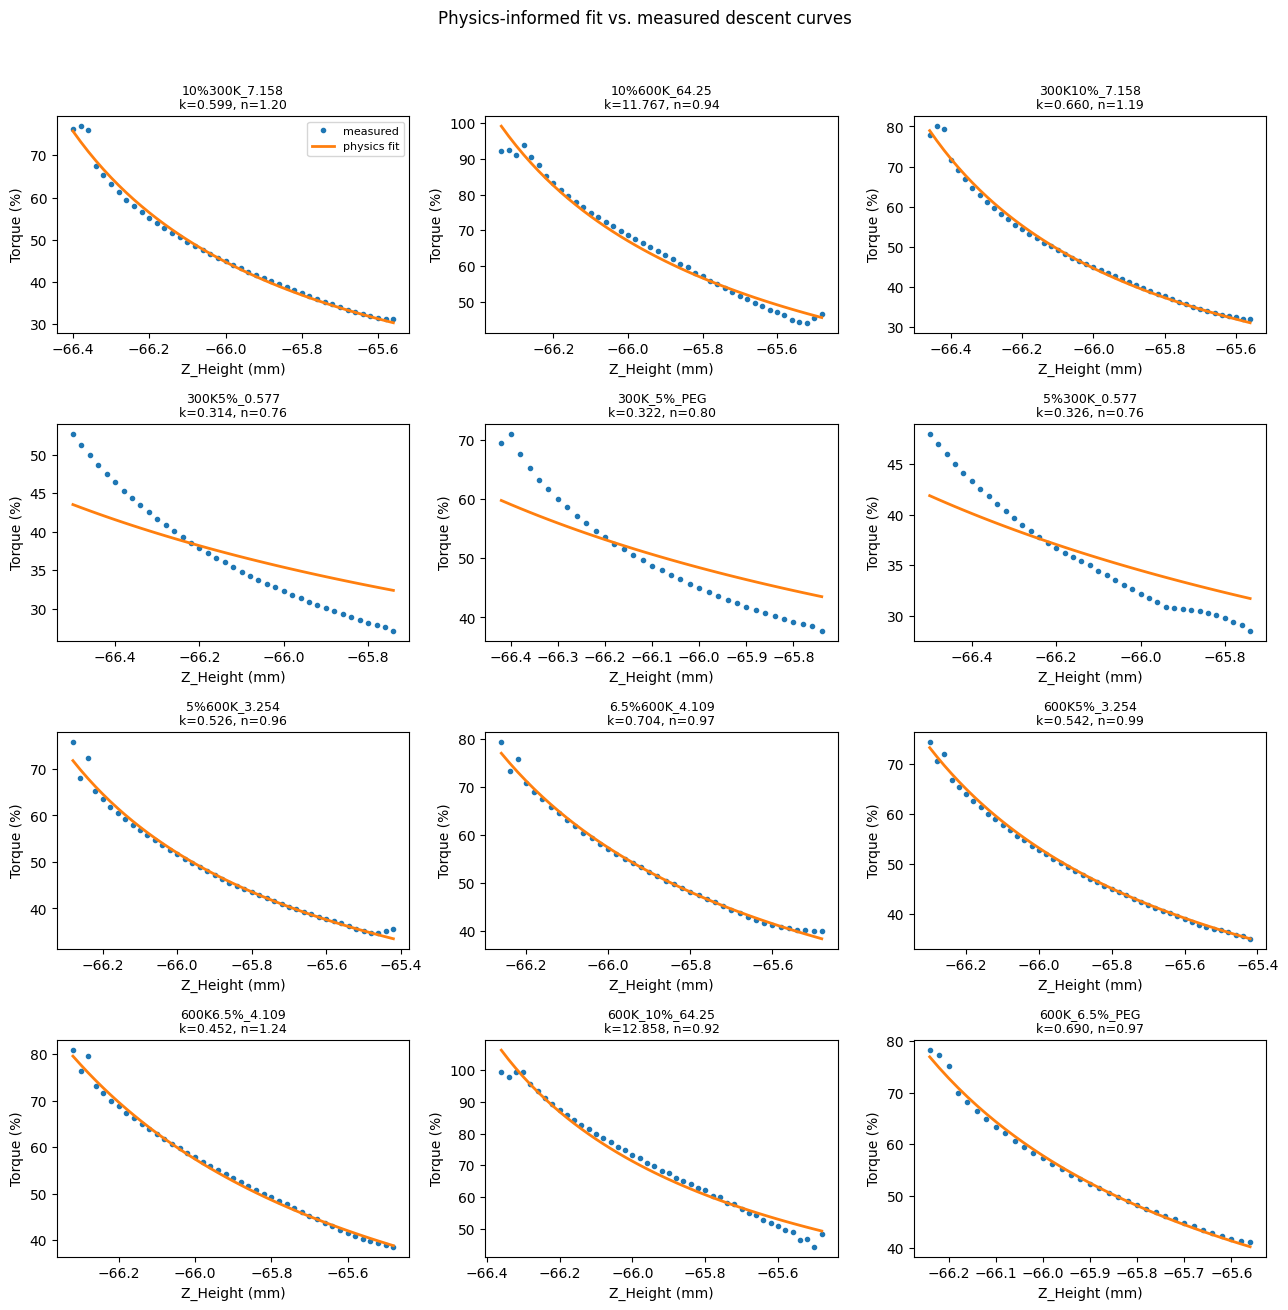

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.2 * n_rows))
for ax, label in zip(axes.flat, labels):
    r = results[label]
    order = np.argsort(r["Z"])
    ax.plot(r["Z"][order], r["y_true"][order], "o", ms=3, label="measured")
    ax.plot(r["Z"][order], r["y_pred"][order], "-", lw=2, label="physics fit")
    ax.set_title(f"{label}\nk={r['k_Pa_sn']:.3f}, n={r['n']:.2f}", fontsize=9)
    ax.set_xlabel("Z_Height (mm)")
    ax.set_ylabel("Torque (%)")
for ax in axes.flat[len(labels):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=8)
fig.suptitle("Physics-informed fit vs. measured descent curves", y=1.02)
plt.tight_layout()
plt.show()

## 7. Fitted power-law parameters

We also pull two extra pieces of information straight out of each label:

- a **canonical sample id** (concentration % + molecular weight), so runs that were re-labelled
  between duplicate tests still get grouped as "the same sample"
- the **trailing number** in the label (e.g. `..._0.577`), which looks like a nominal / reference
  viscosity for that formulation

In [9]:
def parse_label(label):
    pct_match = re.search(r"(\d+\.?\d*)\s*%", label)
    mw_match = re.search(r"(\d+)\s*K", label)
    ref_match = re.search(r"_(\d+\.\d+)$", label)
    pct = float(pct_match.group(1)) if pct_match else np.nan
    mw = f"{mw_match.group(1)}K" if mw_match else "unknown"
    ref_viscosity = float(ref_match.group(1)) if ref_match else np.nan
    return pd.Series({
        "sample_id": f"{mw}_{pct:g}%" if pct_match else mw,
        "mw": mw,
        "pct_peg": pct,
        "ref_viscosity": ref_viscosity,
    })

results_df = pd.DataFrame({
    "label": labels,
    "rpm": [results[l]["rpm"] for l in labels],
    "k_Pa_sn": [results[l]["k_Pa_sn"] for l in labels],
    "n": [results[l]["n"] for l in labels],
    "h0_mm": [results[l]["h0_mm"] for l in labels],
})
results_df = results_df.join(results_df["label"].apply(parse_label))
results_df = results_df.sort_values(["mw", "pct_peg"]).reset_index(drop=True)
results_df

,label,rpm,k_Pa_sn,n,h0_mm,sample_id,mw,pct_peg,ref_viscosity
0,300K5%_0.577,90.0,0.313769,0.761416,-67.463211,300K_5%,300K,5.0,0.577
1,300K_5%_PEG,90.0,0.321941,0.800516,-67.179871,300K_5%,300K,5.0,NaN
2,5%300K_0.577,90.0,0.326051,0.755080,-67.567406,300K_5%,300K,5.0,0.577
3,10%300K_7.158,7.0,0.598879,1.201345,-66.511665,300K_10%,300K,10.0,7.158
4,300K10%_7.158,7.0,0.659610,1.191319,-66.587524,300K_10%,300K,10.0,7.158
5,5%600K_3.254,15.0,0.526235,0.963267,-66.373878,600K_5%,600K,5.0,3.254
6,600K5%_3.254,15.0,0.542066,0.988668,-66.468987,600K_5%,600K,5.0,3.254
7,6.5%600K_4.109,12.0,0.703999,0.974190,-66.385490,600K_6.5%,600K,6.5,4.109
8,600K6.5%_4.109,12.0,0.452221,1.236823,-66.740318,600K_6.5%,600K,6.5,4.109
9,600K_6.5%_PEG,12.0,0.689700,0.967050,-66.333458,600K_6.5%,600K,6.5,NaN


## 8. Sanity checks

**(a) Repeatability** — several samples were run more than once under different label spellings.
If the fit is trustworthy, repeats of the same physical sample should recover similar (k, n).

**(b) Reference-viscosity trend** — we don't know the exact units of the trailing number in each
label, but if the fitted `k` is a physically meaningful consistency index, it should trend
monotonically with that number (for a fluid with `n` close to 1, `k` is approximately the
viscosity itself).

In [10]:
# (a) Repeatability across differently-labelled runs of the same sample
repeat_check = (
    results_df.groupby("sample_id")
    .agg(n_runs=("label", "size"),
         k_mean=("k_Pa_sn", "mean"), k_rel_std=("k_Pa_sn", lambda s: s.std() / s.mean()),
         n_mean=("n", "mean"), n_rel_std=("n", lambda s: s.std() / s.mean()))
    .query("n_runs > 1")
)
repeat_check

,n_runs,k_mean,k_rel_std,n_mean,n_rel_std
sample_id,,,,,
300K_10%,2,0.629244,0.068246,1.196332,0.005926
300K_5%,3,0.320587,0.019501,0.772337,0.031862
600K_10%,2,12.312333,0.062660,0.931907,0.019692
600K_5%,2,0.534151,0.020957,0.975967,0.018403
600K_6.5%,3,0.615307,0.229831,1.059354,0.145120


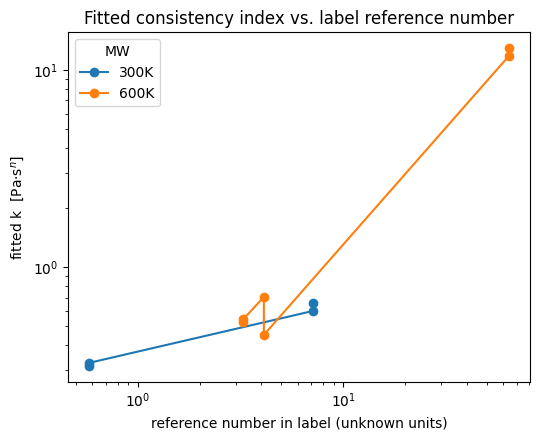

In [11]:
# (b) Fitted k vs. the reference number embedded in each label, per molecular weight
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for mw, g in results_df.groupby("mw"):
    g = g.sort_values("ref_viscosity")
    ax.plot(g["ref_viscosity"], g["k_Pa_sn"], "o-", label=mw)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("reference number in label (unknown units)")
ax.set_ylabel("fitted k  [Pa·s$^n$]")
ax.set_title("Fitted consistency index vs. label reference number")
ax.legend(title="MW")
plt.tight_layout()
plt.show()

## 9. Conclusion & extending to a full 3D PINN

**What we built:** a physics-informed inverse model that reads a raw, zero-uncalibrated cone-plate
descent sweep and recovers the power-law parameters (k, n) *and* the unknown zero-gap offset (h0)
together, by embedding the rotational momentum-balance integral directly in a differentiable
PyTorch forward model and fitting its (unconstrained, physically-reparameterized) parameters with
Adam — the same mechanics used to train a neural network, just with three physical weights instead
of a network's worth.

**Simplifications made here** (worth knowing before trusting the absolute k values):

- *Lubrication / thin-gap approximation* — shear is assumed locally simple (no curvature, no
  secondary flow), valid as long as the gap stays much smaller than the cone radius.
- *Quasi-steady* — inertia and any transient start-up torque are ignored; only the steady drag
  balance is modeled.
- *Cone angle & radius are placeholders* (Section 3) — replace with your real spindle geometry to
  get physically correct k values.
- *No edge or wall-slip effects* at the outer rim of the cone.

**Path to the full 3D PINN** you originally described (PyTorch + DeepXDE / NVIDIA Modulus):

- Replace the analytic lubrication shear-rate formula with a small neural network
  `u_θ(r, φ, z)` representing the actual 3D velocity field in the gap.
- Train it against the full Navier–Stokes momentum residual (evaluated by autograd at randomly
  sampled collocation points in the gap volume) plus no-slip boundary conditions on the plate and
  rotating-cone surfaces — instead of assuming the simple-shear profile we used here.
- Keep `k` and `n` as extra trainable scalars inside the same loss, exactly as we did, so the PDE
  residual and the constitutive law are learned jointly ("inverse PINN").
- This buys you validity outside the thin-gap regime (e.g. near the cone tip, or if the sample
  partially fills the cell) at the cost of a much larger, slower-to-train model — worth it once the
  simplified model here is validated against your actual instrument geometry.